In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("PS_20174392719_1491204439457_log.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
print("Shape of dataset:", df.shape)

Shape of dataset: (6362620, 11)


In [4]:
print(df["isFraud"].value_counts())
print("\nFraud percentage:")
print(df["isFraud"].value_counts(normalize=True) * 100)

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud percentage:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


In [5]:
df = df.drop(columns=["nameOrig", "nameDest"])
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [6]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [7]:
type_mapping = {
    "CASH_IN": 0,
    "CASH_OUT": 1,
    "DEBIT": 2,
    "PAYMENT": 3,
    "TRANSFER": 4
}

df["type"] = df["type"].map(type_mapping)
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,4,181.00,181.0,0.00,0.0,0.0,1,0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [8]:
df = df.rename(columns={
    "type": "types",
    "oldbalanceOrg": "oldbalanceorig",
    "newbalanceOrig": "newbalanceorig",
    "oldbalanceDest": "oldbalancedest",
    "newbalanceDest": "newbalancedest",
    "isFlaggedFraud": "isflaggedfraud",
    "isFraud": "isfraud"
})

df.head()

,step,types,amount,oldbalanceorig,newbalanceorig,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
0,1,3,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,3,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,4,181.00,181.0,0.00,0.0,0.0,1,0
3,1,1,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,3,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [9]:
fraud_df = df[df["isfraud"] == 1]
non_fraud_df = df[df["isfraud"] == 0]

print("Fraud rows:", fraud_df.shape)
print("Non-fraud rows:", non_fraud_df.shape)

Fraud rows: (8213, 9)
Non-fraud rows: (6354407, 9)


In [10]:
balanced_non_fraud = non_fraud_df.sample(n=len(fraud_df) * 3, random_state=42)
balanced_df = pd.concat([fraud_df, balanced_non_fraud], axis=0)

In [11]:
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
balanced_df.head()

,step,types,amount,oldbalanceorig,newbalanceorig,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
0,687,1,371548.21,0.00,0.00,542029.42,913577.63,0,0
1,16,0,189668.51,5785679.12,5975347.63,4457246.94,4488943.53,0,0
2,42,0,127719.54,7129413.96,7257133.50,198588.87,70869.32,0,0
3,135,1,346375.54,0.00,0.00,1237055.11,1583430.65,0,0
4,325,1,93303.86,32939.00,0.00,29770.03,123073.89,0,0


In [12]:
print(balanced_df["isfraud"].value_counts())
print("\nPercentage:")
print(balanced_df["isfraud"].value_counts(normalize=True) * 100)

isfraud
0    24639
1     8213
Name: count, dtype: int64

Percentage:
isfraud
0    75.0
1    25.0
Name: proportion, dtype: float64


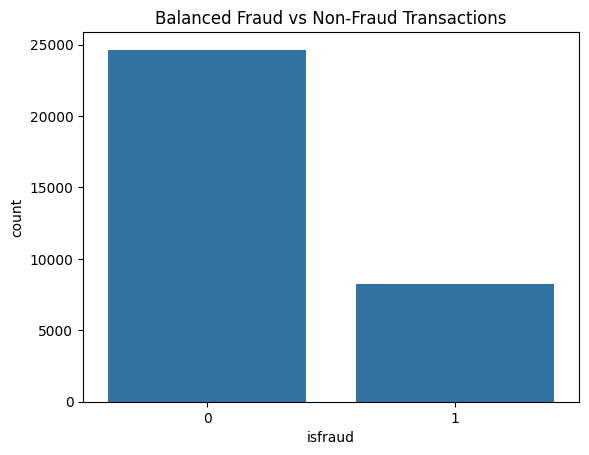

In [13]:
sns.countplot(x="isfraud", data=balanced_df)
plt.title("Balanced Fraud vs Non-Fraud Transactions")
plt.show()

In [14]:
balanced_df.to_csv("balanced_fraud_data.csv", index=False)
print("New balanced dataset saved successfully.")

New balanced dataset saved successfully.


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

In [16]:
df = pd.read_csv("balanced_fraud_data.csv")
df.head()

,step,types,amount,oldbalanceorig,newbalanceorig,oldbalancedest,newbalancedest,isfraud,isflaggedfraud
0,687,1,371548.21,0.00,0.00,542029.42,913577.63,0,0
1,16,0,189668.51,5785679.12,5975347.63,4457246.94,4488943.53,0,0
2,42,0,127719.54,7129413.96,7257133.50,198588.87,70869.32,0,0
3,135,1,346375.54,0.00,0.00,1237055.11,1583430.65,0,0
4,325,1,93303.86,32939.00,0.00,29770.03,123073.89,0,0


In [17]:
X = df.drop("isfraud", axis=1)
y = df["isfraud"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
y_pred = model.predict(X_test)

In [21]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.992695175772333

Confusion Matrix:
 [[4887   32]
 [  16 1636]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      4919
           1       0.98      0.99      0.99      1652

    accuracy                           0.99      6571
   macro avg       0.99      0.99      0.99      6571
weighted avg       0.99      0.99      0.99      6571



In [22]:
joblib.dump(model, "credit_fraud.pkl")
print("Model saved successfully.")

Model saved successfully.


In [23]:
sample = X_test.iloc[[0]]   
prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: [0]


In [24]:
for i in range(5):
    sample = X_test.iloc[[i]]
    print("Predicted:", model.predict(sample), "Actual:", y_test.iloc[i])

Predicted: [0] Actual: 0
Predicted: [0] Actual: 0
Predicted: [0] Actual: 0
Predicted: [1] Actual: 1
Predicted: [0] Actual: 0


In [25]:
import sklearn
import numpy

print("sklearn version:", sklearn.__version__)
print("numpy version:", numpy.__version__)

sklearn version: 1.3.2
numpy version: 1.26.4
